![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E03 - ReAct: Clima y Cálculo
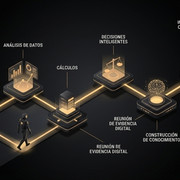

*Figura E03. ReAct encadenando una tool de clima con una tool de calculo.*

## Qué es este ejercicio

Este notebook trabaja un ejemplo autocontenido: consultar clima, usar esa observación y hacer un cálculo con una segunda herramienta.

El objetivo es practicar el patrón ReAct de forma simple: primero observar, después calcular y recién al final responder.

## Consulta del usuario

> "¿Cuál es el clima más reciente en París y cuánto es 5 veces esa temperatura en Celsius?"


## Mapa del patrón ReAct aplicado a este ejemplo

Idea central del patrón:

```text
[Thought] Necesito conocer la temperatura actual de París.
[Action]  weather_tool("Paris")
[Observation] 21°C

[Thought] Ahora debo multiplicar 21 por 5.
[Action]  calculator_tool(21, 5)
[Observation] 105

[Final Answer] La temperatura en París es 21°C y cinco veces esa temperatura es 105°C.
```

Cada etiqueta tiene una función precisa:

| Etiqueta | Función |
|---|---|
| `[Thought]` | El agente razona sobre qué necesita. |
| `[Action]` | El agente elige una tool y la ejecuta. |
| `[Observation]` | El agente lee el resultado de la tool. |
| `[Final Answer]` | El agente responde usando las observaciones. |

Ventaja clave: si imprimes estas etiquetas mientras corre el agente, obtenés un **trace auditable** que podés revisar y depurar.


## Paso 1 - Herramientas disponibles

Definimos dos herramientas.

### `weather_tool`

En producción llamaría a una API real de clima. Acá usamos un mock con datos fijos para que el ejercicio sea ejecutable sin API key.

### `calculator_tool`

En lugar de `eval()` (peligroso), usamos una versión segura con operaciones explícitas.

La seguridad en herramientas explica por qué `eval` es peligroso:

> Si un usuario malicioso envía `__import__("os").system("rm -rf /")`, podría ejecutar comandos peligrosos.

La versión segura acepta solo operaciones conocidas: multiplicar, sumar, restar, dividir.


In [ ]:
# Tool 1: clima con datos mockeados
# En produccion esto llamaria una API real como OpenWeatherMap.

WEATHER_DB = {"Paris": 21, "London": 15, "Berlin": 18, "Buenos Aires": 25}


def weather_tool(ciudad: str) -> dict:
    """
    Tool: devuelve la temperatura actual de una ciudad.
    Retorna dict con success, temperatura y unidad.
    """
    temperatura = WEATHER_DB.get(ciudad)
    if temperatura is None:
        return {"success": False, "error": f"Ciudad no encontrada: {ciudad}"}
    return {"success": True, "ciudad": ciudad, "temperatura_c": temperatura, "unidad": "Celsius"}


# Tool 2: calculadora segura
# Rechaza cualquier input que no sea una operacion conocida.

def calculator_tool(operacion: str, a: float, b: float) -> dict:
    """
    Tool: calculadora segura con operaciones explicitas.
    Operaciones soportadas: multiplicar, sumar, restar, dividir.
    """
    if operacion == "multiplicar":
        return {"success": True, "resultado": a * b}
    if operacion == "sumar":
        return {"success": True, "resultado": a + b}
    if operacion == "restar":
        return {"success": True, "resultado": a - b}
    if operacion == "dividir":
        if b == 0:
            return {"success": False, "error": "No se puede dividir por cero"}
        return {"success": True, "resultado": a / b}
    return {"success": False, "error": f"Operacion no soportada: {operacion}"}


# Debug rapido para verificar que las tools funcionan
print("weather_tool('Paris')       ->", weather_tool("Paris"))
print("calculator_tool('multiplicar', 21, 5) ->", calculator_tool("multiplicar", 21, 5))
print("weather_tool('Tokio')       ->", weather_tool("Tokio"))  # ciudad desconocida


## Paso 2 - Funciones de logging del trace

Una buena práctica de la trazabilidad del agente es **etiquetar cada paso explícitamente**.

Estas funciones de logging van a imprimir las etiquetas ReAct mientras el agente ejecuta.

Esto sirve para:

- ver qué decidió el agente paso a paso,
- detectar en qué paso falló si algo sale mal,
- auditar el comportamiento del sistema.


In [ ]:
def thought(mensaje: str):
    """Imprime el razonamiento del agente."""
    print(f"[Thought] {mensaje}")


def action(nombre_tool: str, *args):
    """Imprime la accion que va a ejecutar el agente."""
    args_str = ", ".join(str(a) for a in args)
    print(f"[Action] {nombre_tool}({args_str})")


def observation(resultado):
    """Imprime la observacion devuelta por una tool."""
    print(f"[Observation] {resultado}")


def final_answer(respuesta: str):
    """Imprime la respuesta final del agente."""
    print(f"[Final Answer] {respuesta}")
    return respuesta


## Paso 3 - TODO: Implementar el agente ReAct

Ahora implementás la función `agente_react(consulta, ciudad)` siguiendo el patrón de la patron ReAct.

### Pasos que debe seguir el agente:

```text
1. [Thought]      Razonar que necesita la temperatura de la ciudad.
2. [Action]       Llamar weather_tool(ciudad).
3. [Observation]  Guardar el resultado.
4. Verificar si la tool tuvo exito. Si no, devolver error seguro.
5. [Thought]      Razonar que ahora necesita multiplicar por 5.
6. [Action]       Llamar calculator_tool("multiplicar", temperatura, 5).
7. [Observation]  Guardar el resultado.
8. [Final Answer] Devolver respuesta con ambos valores.
```

### Importante: fallar de forma segura

> Si una tool falla, el agente **no debe inventar** un número.
> Debe decir que no pudo obtener el dato.

Usá el campo `success` del resultado de la tool para detectar fallos.


In [ ]:
def agente_react(consulta: str, ciudad: str) -> str:
    """
    Agente ReAct minimo: clima + calculo.
    Ejecuta un ejemplo autocontenido de ReAct con una tool de clima y una tool de calculo.
    """
    print(f"[Consulta] {consulta}")
    print()

    # TODO 1: Pensar que se necesita primero.
    # thought("Necesito conocer la temperatura actual de ...")

    # TODO 2: Registrar la accion y llamar weather_tool.
    # action("weather_tool", ciudad)
    # resultado_clima = weather_tool(ciudad)
    # observation(resultado_clima)

    # TODO 3: Verificar exito. Si fallo, devolver:
    # return f"No pude obtener la temperatura de {ciudad}. No voy a estimar el resultado."

    # TODO 4: Extraer la temperatura del resultado.
    # temperatura = resultado_clima["temperatura_c"]

    # TODO 5: Definir la segúnda accion.
    # thought(f"Ahora debo multiplicar {temperatura} por 5.")

    # TODO 6: Registrar la accion y llamar calculator_tool.
    # action("calculator_tool", "multiplicar", temperatura, 5)
    # resultado_calculo = calculator_tool("multiplicar", temperatura, 5)
    # observation(resultado_calculo)

    # TODO 7: Extraer el resultado del calculo.
    # resultado = resultado_calculo["resultado"]

    # TODO 8: Devolver la respuesta final.
    # return final_answer(
    #     f"La temperatura en {ciudad} es {temperatura}°C "
    #     f"y cinco veces esa temperatura es {resultado}°C."
    # )
    pass


## Paso 4 - Ejecutar el agente

Cuando completés los TODOs, la salida esperada es:

```text
[Consulta] ¿Cuál es el clima en París y cuánto es 5 veces esa temperatura?

[Thought] Necesito conocer la temperatura actual de París.
[Action] weather_tool(Paris)
[Observation] {'success': True, 'ciudad': 'Paris', 'temperatura_c': 21, 'unidad': 'Celsius'}
[Thought] Ahora debo multiplicar 21 por 5.
[Action] calculator_tool(multiplicar, 21, 5)
[Observation] {'success': True, 'resultado': 105}
[Final Answer] La temperatura en París es 21°C y cinco veces esa temperatura es 105°C.
```


In [ ]:
CONSULTA = "¿Cuál es el clima en París y cuánto es 5 veces esa temperatura?"
respuesta = agente_react(CONSULTA, "Paris")
print()
print(f"Respuesta del agente: {respuesta}")


## Paso 5 - Verificar el comportamiento ante fallo de tool

Un agente bien diseñado no inventa datos cuando una tool falla.

Probá con una ciudad que no existe en el mock para verificar que el agente responde de forma segura.

Regla práctica:

> "Si una tool falla, el agente no debería inventar. Esto es mejor que alucinar un número."


In [ ]:
print("--- Caso: ciudad desconocida ---")
respuesta_fallo = agente_react("¿Cuál es el clima en Tokio?", "Tokio")
print()
print(f"Respuesta del agente: {respuesta_fallo}")

# La respuesta debería decir que no pudo obtener el dato,
# no inventar un número de temperatura.


## Paso 6 - Checks automáticos

Estos checks verifican el comportamiento correcto del agente.


In [ ]:
def run_checks():
    # Caso normal: ciudad conocida
    respuesta_paris = agente_react("¿Cuál es el clima en París y cuánto es 5 veces?", "Paris")
    assert respuesta_paris is not None, "La respuesta no debe ser None"
    assert "21" in respuesta_paris, "La respuesta debe incluir la temperatura 21"
    assert "105" in respuesta_paris, "La respuesta debe incluir el resultado 105"

    # Caso fallo: ciudad desconocida
    respuesta_fallo = agente_react("¿Cuál es el clima en Tokio?", "Tokio")
    assert respuesta_fallo is not None, "La respuesta de fallo no debe ser None"
    # El agente no debe inventar: la respuesta debe indicar que no pudo obtener el dato
    assert "21" not in respuesta_fallo, "No debe inventar una temperatura"
    assert "105" not in respuesta_fallo, "No debe inventar un calculo"

    print("M3L1 E03 Starter checks passed")


run_checks()


### Cierre

Este notebook termina cuando el agente puede explicar su respuesta a partir de las observaciones generadas por sus herramientas.
